### **1.Consumo di alcol per paese** 
Esegui un’**analisi esplorativa** focalizzata sul **consumo di alcol**.  
Analizza i seguenti aspetti:
* Visualizza i primi 10 paesi ordinati per total_litres_of_pure_alcohol (dal più alto)

* Calcola la media del consumo di birra, vino, e distillati

* Crea una nuova colonna alcohol_index che sia: `(beer_servings + wine_servings + spirit_servings) / 3`

* Trova il paese con il valore massimo di alcohol_index

* Filtra solo i paesi che consumano più di 100 birre all’anno

Crea un bar chart dei 10 paesi con più consumo totale (total_litres_of_pure_alcohol)

Crea un line plot con wine_servings ordinato per paese (usa sort_values)

In [1]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")
df.sort_values(by = 'total_litres_of_pure_alcohol',ascending=False,inplace=True)
df.head(10)

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
15,Belarus,142,373,42,14.4
98,Lithuania,343,244,56,12.9
3,Andorra,245,138,312,12.4
68,Grenada,199,438,28,11.9
61,France,127,151,370,11.8
45,Czech Republic,361,170,134,11.8
141,Russian Federation,247,326,73,11.5
99,Luxembourg,236,133,271,11.4
155,Slovakia,196,293,116,11.4
81,Ireland,313,118,165,11.4


In [9]:
print(f"media della birra = {df.beer_servings.mean()}")
print(f"media del vino = {df.wine_servings.mean()}")
print(f"media dei distillati = {df.spirit_servings.mean()}")

sommaTotale = df.beer_servings.sum() + df.spirit_servings.sum() + df.wine_servings.sum()
entrateTotali = df.beer_servings.count() + df.spirit_servings.count() + df.wine_servings.count()
mediaTotale = sommaTotale/entrateTotali
print(f"media di tutto = {mediaTotale}")

media della birra = 106.16062176165804
media del vino = 49.45077720207254
media dei distillati = 80.99481865284974
media di tutto = 78.86873920552677


In [10]:
df['alcohol_index'] = (df.beer_servings + df.wine_servings + df.spirit_servings)/3
df.head(10)

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,alcohol_index
15,Belarus,142,373,42,14.4,185.666667
98,Lithuania,343,244,56,12.9,214.333333
3,Andorra,245,138,312,12.4,231.666667
68,Grenada,199,438,28,11.9,221.666667
61,France,127,151,370,11.8,216.000000
45,Czech Republic,361,170,134,11.8,221.666667
141,Russian Federation,247,326,73,11.5,215.333333
99,Luxembourg,236,133,271,11.4,213.333333
155,Slovakia,196,293,116,11.4,201.666667
81,Ireland,313,118,165,11.4,198.666667


In [11]:
print(f"Il paese col maggiore con il valore massimo di alcohol index è {df.country[df['alcohol_index'].idxmax()]}")

Il paese col maggiore con il valore massimo di alcohol index è Andorra


In [12]:
df[df['beer_servings'] > 100]

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,alcohol_index
15,Belarus,142,373,42,14.4,185.666667
98,Lithuania,343,244,56,12.9,214.333333
3,Andorra,245,138,312,12.4,231.666667
68,Grenada,199,438,28,11.9,221.666667
61,France,127,151,370,11.8,216.000000
...,...,...,...,...,...,...
29,Cabo Verde,144,56,16,4.0,72.000000
170,Macedonia,106,27,86,3.9,73.000000
20,Bolivia,167,41,8,3.8,72.000000
146,Samoa,105,18,24,2.6,49.000000


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Belarus'),
  Text(1, 0, 'Lithuania'),
  Text(2, 0, 'Andorra'),
  Text(3, 0, 'Grenada'),
  Text(4, 0, 'France'),
  Text(5, 0, 'Czech Republic'),
  Text(6, 0, 'Russian Federation'),
  Text(7, 0, 'Luxembourg'),
  Text(8, 0, 'Slovakia'),
  Text(9, 0, 'Ireland')])

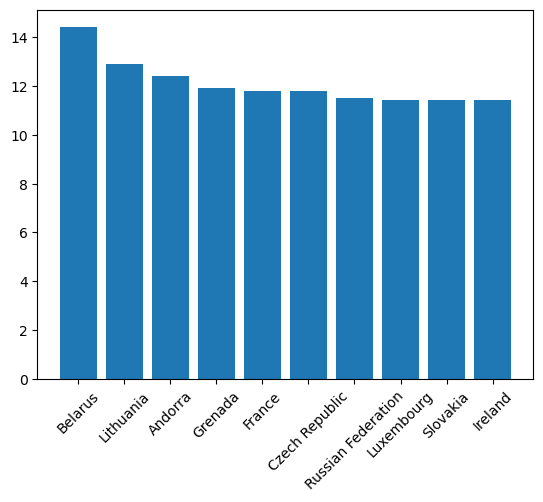

In [14]:
import matplotlib.pyplot as plt

plt.bar(df.sort_values(by = 'total_litres_of_pure_alcohol',ascending=False,inplace=False).country.head(10),df.sort_values(by = 'total_litres_of_pure_alcohol',ascending=False,inplace=False).total_litres_of_pure_alcohol.head(10))
plt.xticks(rotation = 45)

(array([-25.,   0.,  25.,  50.,  75., 100., 125., 150., 175., 200., 225.]),
 [Text(-25.0, 0, 'Sudan'),
  Text(0.0, 0, 'France'),
  Text(25.0, 0, 'Georgia'),
  Text(50.0, 0, 'Poland'),
  Text(75.0, 0, 'Micronesia'),
  Text(100.0, 0, 'Nauru'),
  Text(125.0, 0, 'Djibouti'),
  Text(150.0, 0, 'DR Congo'),
  Text(175.0, 0, 'Indonesia'),
  Text(200.0, 0, ''),
  Text(225.0, 0, '')])

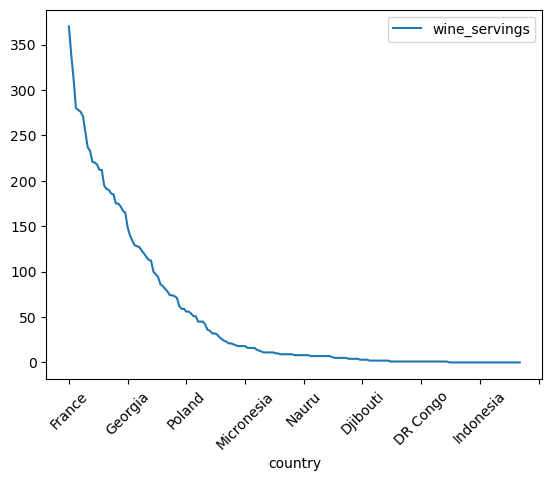

In [15]:
df.sort_values(by='wine_servings',ascending=False,inplace=False).plot(x='country', y='wine_servings')

plt.xticks(rotation = 45)

### **2.Analisi offerte di lavoro** 

Esegui un’**analisi esplorativa** focalizzata sui **lavori nel campo dei dati in ciascun paese**.  
Analizza i seguenti aspetti per ogni paese:

* Lo **stipendio medio annuale** (`salary_year_avg`)
* Il **numero totale di offerte di lavoro** (job count)
* L’intervallo degli stipendi: **valore minimo e massimo** (`min` / `max`)

Rappresenta graficamente lo stipendio medio (`salary_year_avg`) per `job_title_short` usando un grafico a barre orizzontali. Ordina i dati dallo stipendio più alto al più basso. Includi un titolo e le etichette per gli assi x e y.

In [4]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

df.groupby("search_location").agg({
    'salary_year_avg':['mean','min','max'],
    'search_location':'count',
})


salary_year_avg                    search_location
                               mean      min       max           count
search_location                                                       
Afghanistan                     NaN      NaN       NaN              16
Albania                79472.500000  43200.0  157500.0             119
Algeria                44550.000000  44100.0   45000.0             111
Angola                          NaN      NaN       NaN              11
Antigua and Barbuda             NaN      NaN       NaN               2
...                             ...      ...       ...             ...
Vietnam                90927.236364  28000.0  200000.0            2414
Western Sahara                  NaN      NaN       NaN               2
Yemen                           NaN      NaN       NaN              10
Zambia                 90670.000000  90670.0   90670.0             104
Zimbabwe               67056.666667  47500.0   90670.0              81

[173 rows x 4 columns]

<BarContainer object of 10 artists>

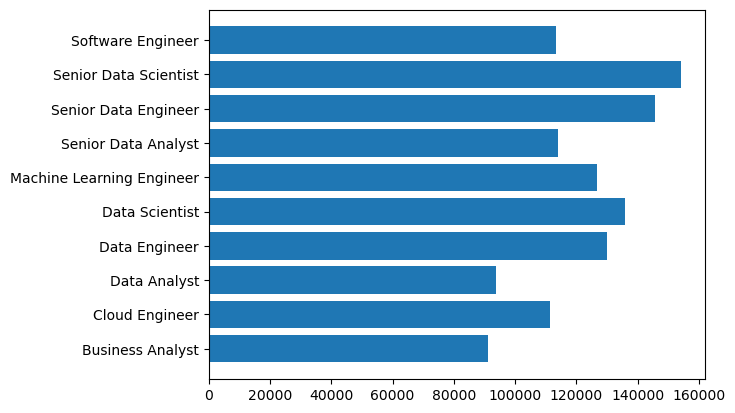

In [6]:
coso = df.groupby("job_title_short")['salary_year_avg'].mean().reset_index()
plt.barh(coso.job_title_short, coso.salary_year_avg)

### **3. Analisi vendite (dataset tips)**

Esegui un’**analisi esplorativa** focalizzata sulle **vendite giornaliere**.  
Analizza i seguenti aspetti per ogni giorno (`day`):

* Il **conto medio** (`total_bill`)
* Il **numero totale di osservazioni** (conteggio delle righe)
* Il **valore minimo e massimo** del conto (`total_bill` → `min` / `max`)

* Crea una nuova colonna `conto_per_persona` che sia:  
  `total_bill / size`

* Trova il giorno con il **conto medio più alto**

Rappresenta graficamente il **conto medio (`total_bill`) per giorno** usando un **grafico a barre**.  
Ordina i dati dal valore più alto al più basso.  
Aggiungi titolo ed etichette agli assi.

In [37]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

df.groupby("day").agg({
    'total_bill':['mean','min','max'],
    'day':'count',
})




total_bill                day
           mean   min    max count
day                               
Fri   17.151579  5.75  40.17    19
Sat   20.441379  3.07  50.81    87
Sun   21.410000  7.25  48.17    76
Thur  17.682742  7.51  43.11    62

In [46]:
df['conto_per_persona'] = df.total_bill/df['size']
df.head(10)


,total_bill,tip,sex,smoker,day,time,size,conto_per_persona
0,16.99,1.01,Female,No,Sun,Dinner,2,8.495000
1,10.34,1.66,Male,No,Sun,Dinner,3,3.446667
2,21.01,3.50,Male,No,Sun,Dinner,3,7.003333
3,23.68,3.31,Male,No,Sun,Dinner,2,11.840000
4,24.59,3.61,Female,No,Sun,Dinner,4,6.147500
5,25.29,4.71,Male,No,Sun,Dinner,4,6.322500
6,8.77,2.00,Male,No,Sun,Dinner,2,4.385000
7,26.88,3.12,Male,No,Sun,Dinner,4,6.720000
8,15.04,1.96,Male,No,Sun,Dinner,2,7.520000
9,14.78,3.23,Male,No,Sun,Dinner,2,7.390000


In [51]:
coso = df.groupby("day")["total_bill"].sum()
print(f"Il giorno col maggiore numero di vendite è {coso.idxmax()} con un totale di {coso.max()}")

Il giorno col maggiore numero di vendite è Sat con un totale di 1778.4
